In [1]:
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

IMAGE_SIZE = 64
CHANNELS_IMG = 3
DRONE_CLASSES = 11
LATENT_DIM = 100
EMBED_SIZE = 100
FEATURES_G = 64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUTPUT_DIR = "synthetic_drone_leaves"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [2]:
class Generator(nn.Module):
    def __init__(self, num_classes, latent_dim, embed_size, img_channels, features_g):
        super(Generator, self).__init__()
        self.embed = nn.Embedding(num_classes, embed_size)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim + embed_size, features_g * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(features_g * 8),
            nn.ReLU(True),
            nn.ConvTranspose2d(features_g * 8, features_g * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_g * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(features_g * 4, features_g * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_g * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(features_g * 2, features_g, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features_g),
            nn.ReLU(True),
            nn.ConvTranspose2d(features_g, img_channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        embedding = self.embed(labels).unsqueeze(2).unsqueeze(3)
        x = torch.cat([noise, embedding], dim=1)
        return self.net(x)

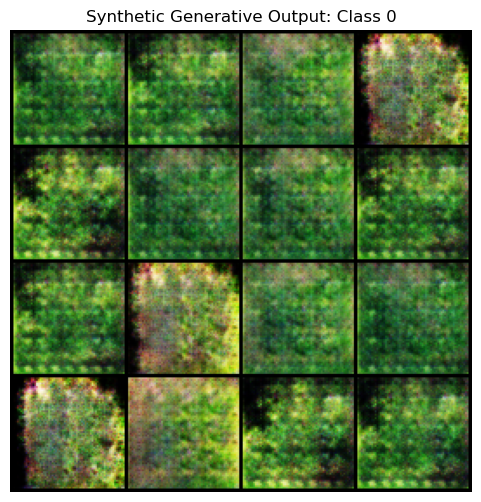

Batch saved successfully to: synthetic_drone_leaves\class_0_synthetic.png


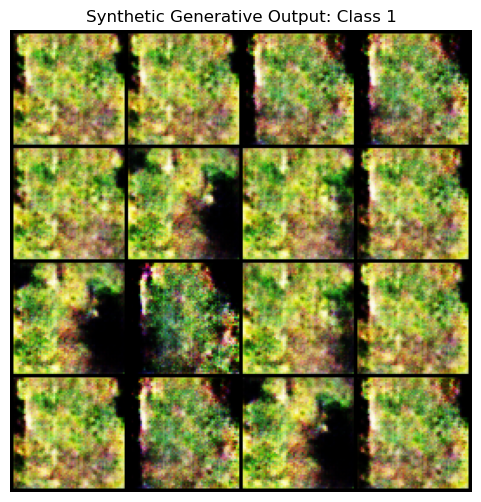

Batch saved successfully to: synthetic_drone_leaves\class_1_synthetic.png


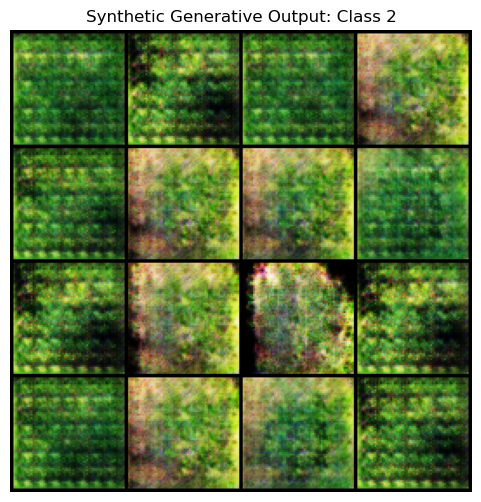

Batch saved successfully to: synthetic_drone_leaves\class_2_synthetic.png


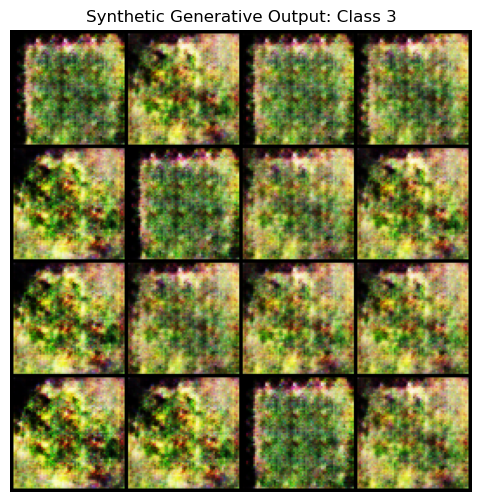

Batch saved successfully to: synthetic_drone_leaves\class_3_synthetic.png


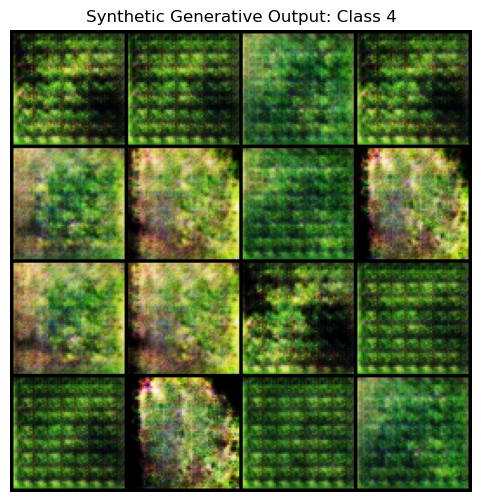

Batch saved successfully to: synthetic_drone_leaves\class_4_synthetic.png


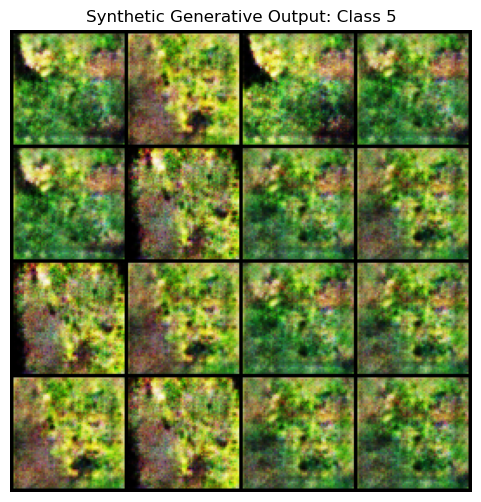

Batch saved successfully to: synthetic_drone_leaves\class_5_synthetic.png


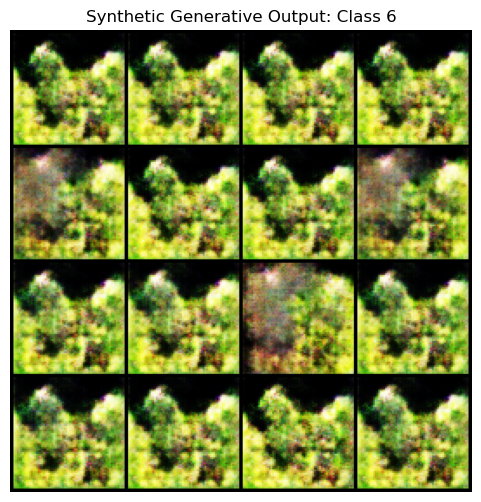

Batch saved successfully to: synthetic_drone_leaves\class_6_synthetic.png


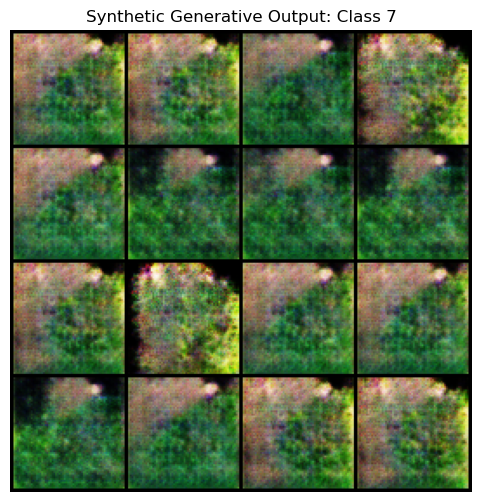

Batch saved successfully to: synthetic_drone_leaves\class_7_synthetic.png


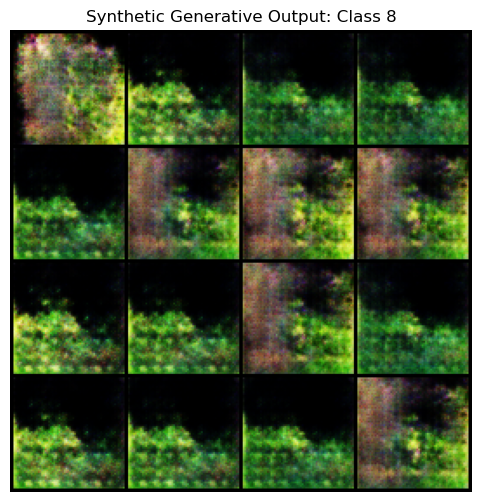

Batch saved successfully to: synthetic_drone_leaves\class_8_synthetic.png


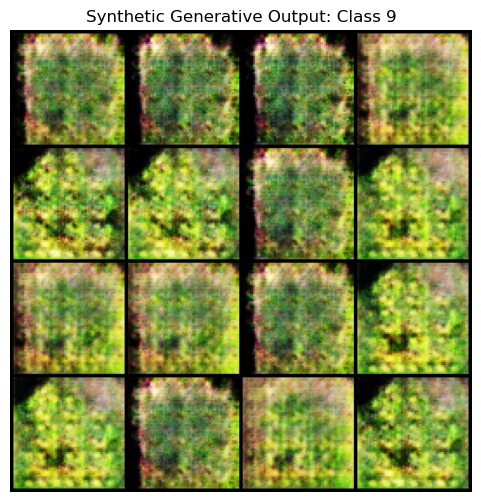

Batch saved successfully to: synthetic_drone_leaves\class_9_synthetic.png


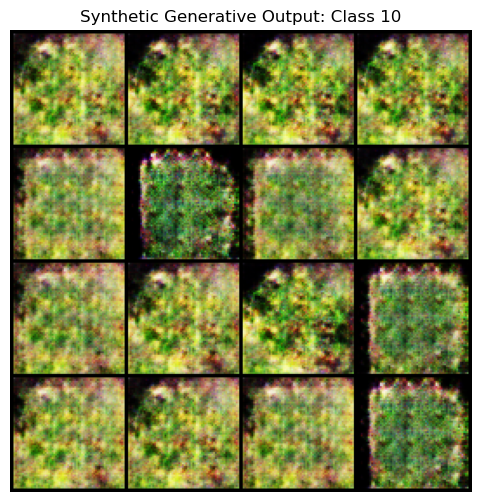

Batch saved successfully to: synthetic_drone_leaves\class_10_synthetic.png


In [3]:
model = Generator(DRONE_CLASSES, LATENT_DIM, EMBED_SIZE, CHANNELS_IMG, FEATURES_G).to(DEVICE)
model.load_state_dict(torch.load("models/drone_generator.pth", map_location=DEVICE))
model.eval()

def generate_synthetic_samples(target_class, num_samples=16):
    """Generates synthetic images for a designated leaf/disease category index"""
    with torch.no_grad():
        noise = torch.randn(num_samples, LATENT_DIM, 1, 1).to(DEVICE)
        labels = torch.full((num_samples,), target_class, dtype=torch.long).to(DEVICE)
        
        synthetic_imgs = model(noise, labels).cpu()
        
        synthetic_imgs = (synthetic_imgs * 0.5) + 0.5
        
        grid = make_grid(synthetic_imgs, nrow=4)
        output_path = os.path.join(OUTPUT_DIR, f"class_{target_class}_synthetic.png")
        
        plt.figure(figsize=(6, 6))
        plt.imshow(grid.permute(1, 2, 0))
        plt.title(f"Synthetic Generative Output: Class {target_class}")
        plt.axis("off")
        plt.savefig(output_path, bbox_inches='tight')
        plt.show()
        
        print(f"Batch saved successfully to: {output_path}")

for class_idx in range(DRONE_CLASSES):
    generate_synthetic_samples(target_class=class_idx, num_samples=16)